# Neural Network for Handwritten Digit Classification
### Coding Ninjas 10X — AI-ML Recruitment Task (Second Years) · Task 2

**Candidate:** Ali Ahmad
**Dataset:** [MNIST Handwritten Digit Database](http://yann.lecun.com/exdb/mnist/) — 70,000
grayscale images of handwritten digits (0–9), the classic benchmark for image classification.

**Objective:** build a simple neural network from its basic components, train it, and understand
*why* each component (activation functions, layers, hyperparameters) is there — not just get a
high accuracy number.

| Part | Content |
|---|---|
| A | Dataset understanding |
| B | Data preprocessing |
| C | Building the neural network |
| D | Activation functions |
| E | Training |
| F | Evaluation |
| G | Experimentation |

> This notebook is self-contained — the dataset is downloaded automatically in Part A. Run it
> top-to-bottom with **Runtime → Run all** (takes roughly a minute on Colab's default CPU runtime).

In [15]:
import os, urllib.request, warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Part A – Dataset Understanding

**What is MNIST?** The Modified National Institute of Standards and Technology (MNIST) database
is a collection of **70,000 grayscale images of handwritten digits (0–9)** — 60,000 for training
and 10,000 for testing — each a **28×28 pixel** square, centered and size-normalized. It has been
the standard "hello world" benchmark for image classification since the late 1990s: simple enough
to train quickly, but non-trivial enough to meaningfully compare models.

- **Input image dimensions:** 28 × 28 pixels, single (grayscale) channel — 784 pixel values per image.
- **Number of classes:** 10 — the digits 0 through 9.
- **What the labels represent:** each label is an integer 0–9 stating which digit the corresponding
  image actually shows — the ground truth the network is trained to predict.

We confirm all of this directly from the data once it's loaded below, rather than just asserting it.

In [16]:
# The dataset is fetched from the official Keras/TensorFlow host. If that host is unreachable
# (e.g. a restricted network), we fall back to a verified GitHub-hosted mirror of the exact same
# 70,000 images, converted back to the same standard (60,000/10,000, uint8, 0-9 label) format.

def load_mnist():
    try:
        print("Loading MNIST via the official tf.keras.datasets loader...")
        (x_tr, y_tr), (x_te, y_te) = keras.datasets.mnist.load_data()
        print("Loaded from the official source.")
        return x_tr, y_tr, x_te, y_te
    except Exception as e:
        print(f"Official source unreachable ({type(e).__name__}). Falling back to mirror...")
        mirror_url = ("https://raw.githubusercontent.com/SebLague/"
                       "Mnist-data-numpy-format/master/mnist.npz")
        local_path = "mnist_mirror.npz"
        if not os.path.exists(local_path):
            urllib.request.urlretrieve(mirror_url, local_path)
        data = np.load(local_path)

        def _to_standard(images_flat_01, labels_onehot):
            imgs = (images_flat_01.reshape(-1, 28, 28) * 255).round().astype("uint8")
            labs = np.argmax(labels_onehot.reshape(labels_onehot.shape[0], -1), axis=1).astype("uint8")
            return imgs, labs

        x_tr1, y_tr1 = _to_standard(data["training_images"], data["training_labels"])
        x_val, y_val = _to_standard(data["validation_images"], data["validation_labels"])
        x_te, y_te   = _to_standard(data["test_images"], data["test_labels"])
        x_tr = np.concatenate([x_tr1, x_val]); y_tr = np.concatenate([y_tr1, y_val])
        print("Loaded from mirror and reconstructed the standard 60,000 / 10,000 split.")
        return x_tr, y_tr, x_te, y_te

x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_mnist()

print(f"\nx_train: {x_train_raw.shape}  dtype={x_train_raw.dtype}  range=[{x_train_raw.min()}, {x_train_raw.max()}]")
print(f"y_train: {y_train_raw.shape}  classes={sorted(np.unique(y_train_raw).tolist())}")
print(f"x_test : {x_test_raw.shape}")
print(f"y_test : {y_test_raw.shape}")

Loading MNIST via the official tf.keras.datasets loader...
Loaded from the official source.

x_train: (60000, 28, 28)  dtype=uint8  range=[0, 255]
y_train: (60000,)  classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
x_test : (10000, 28, 28)
y_test : (10000,)


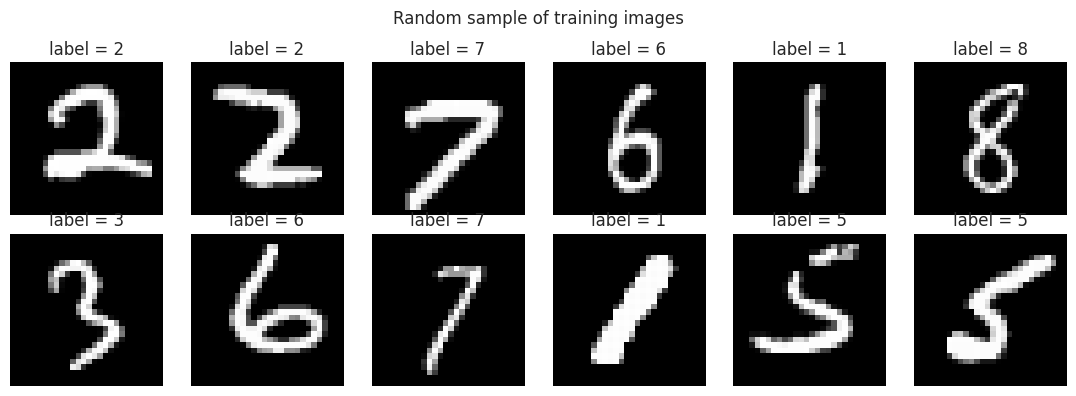

Training samples per digit class:
[5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [17]:
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_train_raw), size=12, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_train_raw[idx], cmap="gray")
    ax.set_title(f"label = {y_train_raw[idx]}")
    ax.axis("off")
plt.suptitle("Random sample of training images")
plt.tight_layout()
plt.show()

print("Training samples per digit class:")
print(np.bincount(y_train_raw))

The dataset is close to (though not perfectly) balanced across the 10 digit classes — good news,
since a heavily imbalanced dataset would need extra handling (class weights, resampling) before
accuracy became a trustworthy metric.

## Part B – Data Preprocessing

In [18]:
print(f"Raw pixel dtype : {x_train_raw.dtype}")
print(f"Raw pixel range : [{x_train_raw.min()}, {x_train_raw.max()}]")

# Normalize pixel values from [0, 255] integers to [0, 1] floats
x_train = x_train_raw.astype("float32") / 255.0
x_test  = x_test_raw.astype("float32") / 255.0

print(f"\nNormalized dtype : {x_train.dtype}")
print(f"Normalized range : [{x_train.min():.3f}, {x_train.max():.3f}]")

Raw pixel dtype : uint8
Raw pixel range : [0, 255]

Normalized dtype : float32
Normalized range : [0.000, 1.000]


**Why normalize?** Neural networks train via gradient descent, which is sensitive to the *scale*
of the inputs. Raw pixel values up to 255 would produce disproportionately large activations and
gradients in the very first layer, making training slower and less stable. Rescaling to `[0, 1]`
keeps every input feature on a comparable, small scale, which in practice means faster, more
stable convergence.

In [19]:
# Labels are kept as plain integers (0-9) rather than one-hot vectors, since we pair them with
# Keras's "sparse" categorical cross-entropy loss below (mathematically identical, less memory).
y_train, y_test = y_train_raw.astype("int64"), y_test_raw.astype("int64")

print("A single training image, before the model's own Flatten layer, has shape:", x_train[0].shape)
print("After flattening it into one feature vector, it would have shape       :", x_train[0].flatten().shape)
print(f"\nFinal arrays -> x_train {x_train.shape}, y_train {y_train.shape}, x_test {x_test.shape}, y_test {y_test.shape}")

A single training image, before the model's own Flatten layer, has shape: (28, 28)
After flattening it into one feature vector, it would have shape       : (784,)

Final arrays -> x_train (60000, 28, 28), y_train (60000,), x_test (10000, 28, 28), y_test (10000,)


**Do we need to reshape/flatten?** A plain (fully-connected) network needs a 1-D feature vector
per example, not a 2-D image, since every `Dense` layer connects to a flat list of inputs. We
*could* flatten `x_train`/`x_test` to `(n, 784)` right now with `.reshape(-1, 784)` — but instead
we keep the images as `(28, 28)` and let a `Flatten` layer do this inside the model itself (built
next). That way the model's input shape documents what a "real" input image looks like, and the
exact same arrays could be reused unmodified by a convolutional model later, which expects 2-D
images rather than flat vectors.

## Part C – Build the Neural Network

In [20]:
def build_model(hidden_units=128, hidden_activation="relu", seed=SEED):
    tf.random.set_seed(seed)
    model = keras.Sequential([
        layers.Input(shape=(28, 28), name="input_image"),
        layers.Flatten(name="flatten_to_784"),
        layers.Dense(hidden_units, activation=hidden_activation, name="hidden_layer"),
        layers.Dense(10, activation="softmax", name="output_layer"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline_model = build_model(hidden_units=128, hidden_activation="relu")
baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_to_784 (Flatten)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**What each component does:**
- **Input layer** — declares the shape of one example (`28×28`). It doesn't transform anything;
  it just tells the model what to expect.
- **Flatten** — reshapes each `28×28` image into a single 784-length vector, since the `Dense`
  layer that follows expects a flat list of numbers, not a 2-D grid.
- **Hidden layer (`Dense`, 128 units, ReLU)** — the network's actual "reasoning" layer. Every one
  of its 128 neurons looks at all 784 pixel values and learns its own weighted combination of
  them; stacking many such neurons lets the network build up increasingly abstract features
  (edges, then curves, then digit-like shapes) rather than memorizing raw pixels.
- **Output layer (`Dense`, 10 units, Softmax)** — produces one score per digit class, converted
  by Softmax into a probability distribution over the 10 possible digits (Part D covers exactly
  how and why).

The model summary above also reports **101,770 trainable parameters** — every one of those is a
weight or bias the network will adjust during training to reduce its prediction error.

## Part D – Activation Functions

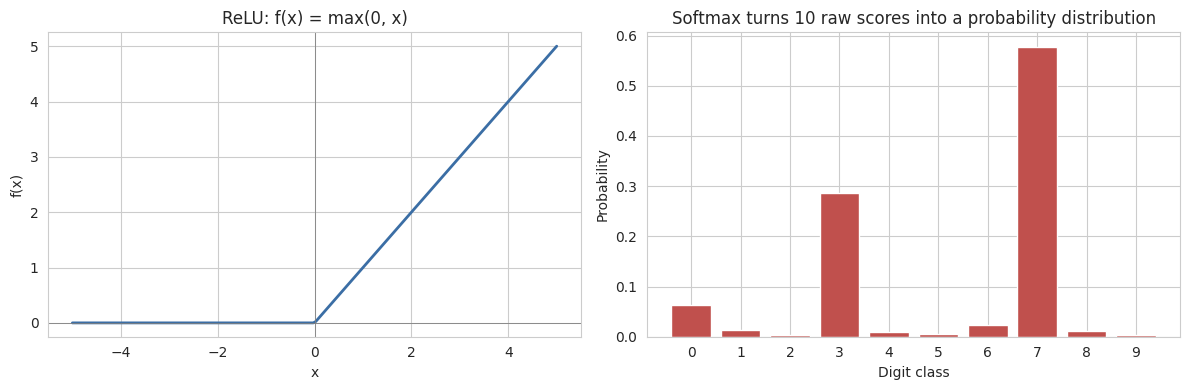

Example raw output scores (logits): [ 2.   0.5 -1.   3.5  0.1 -0.5  1.   4.2  0.3 -0.8]
After Softmax (sums to 1.0 ): [0.064 0.014 0.003 0.287 0.01  0.005 0.024 0.578 0.012 0.004]


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- ReLU ---
x = np.linspace(-5, 5, 200)
relu = np.maximum(0, x)
axes[0].plot(x, relu, color="#3b6ea5", linewidth=2)
axes[0].set_title("ReLU: f(x) = max(0, x)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].axhline(0, color="grey", linewidth=0.6); axes[0].axvline(0, color="grey", linewidth=0.6)

# --- Softmax on a toy example logit vector ---
example_logits = np.array([2.0, 0.5, -1.0, 3.5, 0.1, -0.5, 1.0, 4.2, 0.3, -0.8])
example_probs = tf.nn.softmax(example_logits).numpy()
axes[1].bar(range(10), example_probs, color="#c0504d")
axes[1].set_title("Softmax turns 10 raw scores into a probability distribution")
axes[1].set_xlabel("Digit class"); axes[1].set_ylabel("Probability")
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()

print("Example raw output scores (logits):", np.round(example_logits, 2))
print("After Softmax (sums to", round(example_probs.sum(), 3), "):", np.round(example_probs, 3))

**Why activation functions at all?** Without a non-linear activation between layers, stacking
several `Dense` layers would collapse mathematically into a single linear transformation — no
matter how many layers you add, the network could still only learn straight-line (linear)
decision boundaries. Activation functions introduce **non-linearity**, letting the network
approximate the far more complex, curved decision boundaries needed to tell handwritten digits apart.

**Why ReLU in the hidden layer?** `ReLU(x) = max(0, x)` is simple and cheap to compute, and its
gradient is either exactly 0 or exactly 1 — it doesn't shrink toward zero for large inputs the way
sigmoid/tanh do (a problem called the **vanishing gradient**), so networks using it tend to train
faster and more reliably. Part G below tests this claim directly rather than just asserting it.

**Why Softmax on the output layer?** This is a **10-class, mutually-exclusive** classification
problem — each image is exactly one digit. Softmax converts the 10 raw output scores into a
probability distribution that (a) is entirely non-negative, and (b) sums to exactly 1, so
`model.predict(...)` directly gives "the probability this image is a 3", "...is a 7", etc., and
the single largest one is the network's actual prediction.

## Part E – Training

In [22]:
EPOCHS = 10
BATCH_SIZE = 128

history = baseline_model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,   # last 10% of the training set, held out purely for monitoring
    verbose=2,
)

Epoch 1/10
422/422 - 3s - 7ms/step - accuracy: 0.8959 - loss: 0.3830 - val_accuracy: 0.9550 - val_loss: 0.1734
Epoch 2/10
422/422 - 2s - 4ms/step - accuracy: 0.9477 - loss: 0.1806 - val_accuracy: 0.9633 - val_loss: 0.1321
Epoch 3/10
422/422 - 2s - 5ms/step - accuracy: 0.9616 - loss: 0.1314 - val_accuracy: 0.9680 - val_loss: 0.1119
Epoch 4/10
422/422 - 3s - 7ms/step - accuracy: 0.9710 - loss: 0.1019 - val_accuracy: 0.9725 - val_loss: 0.1007
Epoch 5/10
422/422 - 2s - 6ms/step - accuracy: 0.9767 - loss: 0.0819 - val_accuracy: 0.9740 - val_loss: 0.0935
Epoch 6/10
422/422 - 2s - 4ms/step - accuracy: 0.9812 - loss: 0.0675 - val_accuracy: 0.9750 - val_loss: 0.0888
Epoch 7/10
422/422 - 2s - 4ms/step - accuracy: 0.9844 - loss: 0.0563 - val_accuracy: 0.9752 - val_loss: 0.0858
Epoch 8/10
422/422 - 2s - 4ms/step - accuracy: 0.9874 - loss: 0.0472 - val_accuracy: 0.9753 - val_loss: 0.0838
Epoch 9/10
422/422 - 2s - 4ms/step - accuracy: 0.9897 - loss: 0.0397 - val_accuracy: 0.9760 - val_loss: 0.0835
E

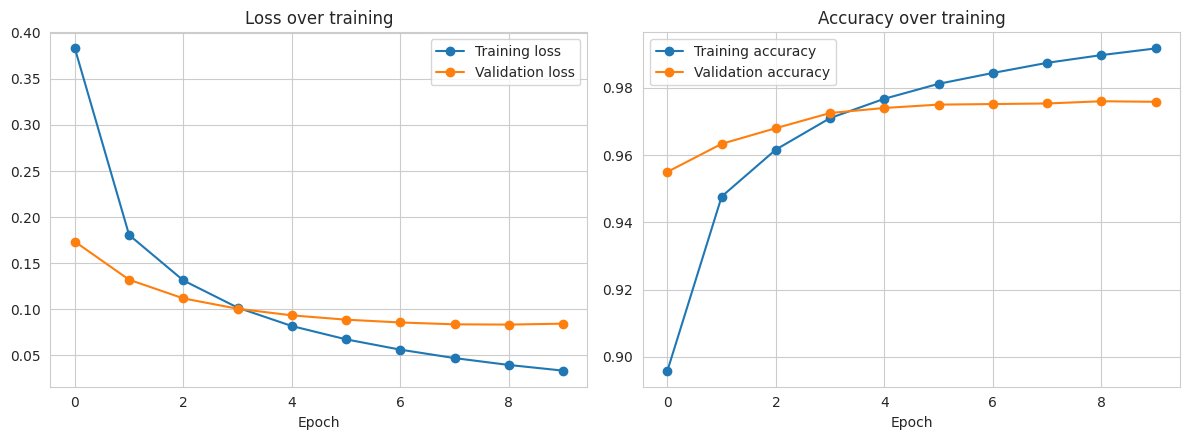

Final training accuracy  : 0.9917
Final validation accuracy: 0.9758
Final training loss      : 0.0336
Final validation loss    : 0.0845


In [23]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(h["loss"], marker="o", label="Training loss")
axes[0].plot(h["val_loss"], marker="o", label="Validation loss")
axes[0].set_title("Loss over training"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(h["accuracy"], marker="o", label="Training accuracy")
axes[1].plot(h["val_accuracy"], marker="o", label="Validation accuracy")
axes[1].set_title("Accuracy over training"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Final training accuracy  : {h['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {h['val_accuracy'][-1]:.4f}")
print(f"Final training loss      : {h['loss'][-1]:.4f}")
print(f"Final validation loss    : {h['val_loss'][-1]:.4f}")

Both curves improve quickly in the first 2–3 epochs and then level off. Training accuracy keeps
climbing a little further than validation accuracy does over the later epochs — a small,
expected train/validation gap opening up (the model is starting to fit some training-set-specific
noise), though nowhere near severe overfitting.

## Part F – Evaluation

In [24]:
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test, verbose=0)
print(f"TEST accuracy: {test_accuracy:.4f}")
print(f"TEST loss    : {test_loss:.4f}")

y_pred_proba = baseline_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

TEST accuracy: 0.9748
TEST loss    : 0.0803


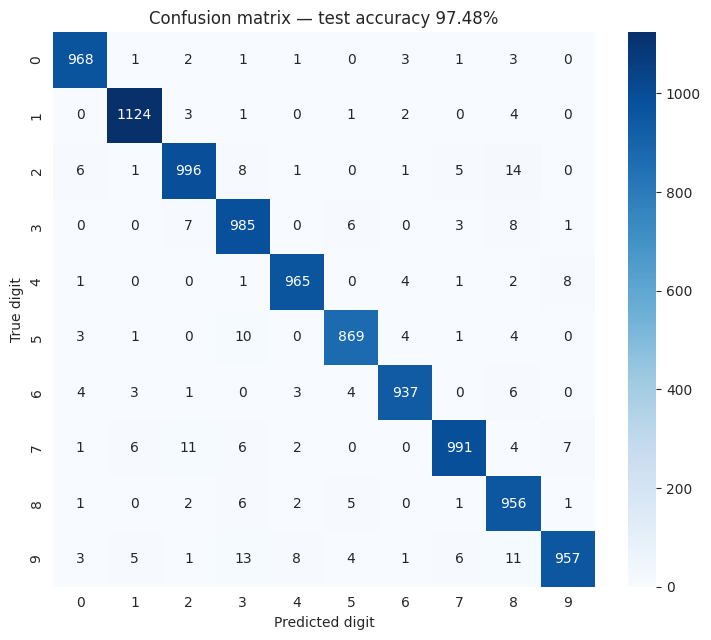

In [25]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel("Predicted digit"); ax.set_ylabel("True digit")
ax.set_title(f"Confusion matrix — test accuracy {test_accuracy:.2%}")
plt.tight_layout()
plt.show()

In [26]:
print(classification_report(y_test, y_pred, digits=3))

cm_offdiag = cm.copy(); np.fill_diagonal(cm_offdiag, 0)
top_confusions = np.dstack(np.unravel_index(np.argsort(-cm_offdiag.ravel())[:5], cm_offdiag.shape))[0]
print("Most common misclassifications (true -> predicted : count):")
for t, p in top_confusions:
    print(f"  {t} -> {p} : {cm[t, p]}")

              precision    recall  f1-score   support

           0      0.981     0.988     0.984       980
           1      0.985     0.990     0.988      1135
           2      0.974     0.965     0.969      1032
           3      0.955     0.975     0.965      1010
           4      0.983     0.983     0.983       982
           5      0.978     0.974     0.976       892
           6      0.984     0.978     0.981       958
           7      0.982     0.964     0.973      1028
           8      0.945     0.982     0.963       974
           9      0.983     0.948     0.965      1009

    accuracy                          0.975     10000
   macro avg      0.975     0.975     0.975     10000
weighted avg      0.975     0.975     0.975     10000

Most common misclassifications (true -> predicted : count):
  2 -> 8 : 14
  9 -> 3 : 13
  7 -> 2 : 11
  9 -> 8 : 11
  5 -> 3 : 10


**What the confusion matrix tells us:** the diagonal holds the correct predictions — heavily
dominant here, matching the overall test accuracy above. The (usually small) off-diagonal counts
show exactly *which* digits the model mixes up: the pairs printed above are the network's most
frequent mistakes. These tend to be digits that genuinely look alike when handwritten — e.g. a
hastily-written **9** can easily resemble a **4** or an **8**, and a **7** can resemble a **2** —
so the confusion matrix isn't just a score, it's a diagnostic tool pointing at *which* visual
distinctions the model still finds hardest. Precision, recall, and F1 per digit (printed above)
tell the same story per-class: a class with recall well below its precision is one the model
under-predicts (it's cautious about guessing that digit), and vice versa.

## Part G – Experimentation

**What we're changing:** the hidden layer's activation function — **ReLU → Sigmoid** — with
absolutely everything else (architecture, optimizer, epochs, batch size, random seed) held fixed.

**Hypothesis, from Part D:** sigmoid squashes its input into `(0, 1)` and **saturates** (flattens
out, producing tiny gradients) for inputs far from zero. We'd expect this to train *more slowly*
than ReLU and plausibly land at a *slightly lower* final accuracy, even in a shallow, one-hidden-layer
network like this one where the effect has less room to compound than it would in a deep network.

In [27]:
sigmoid_model = build_model(hidden_units=128, hidden_activation="sigmoid")

history_sigmoid = sigmoid_model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=2,
)

test_loss_sig, test_accuracy_sig = sigmoid_model.evaluate(x_test, y_test, verbose=0)
print(f"\nSigmoid-hidden-layer TEST accuracy: {test_accuracy_sig:.4f}   TEST loss: {test_loss_sig:.4f}")

Epoch 1/10
422/422 - 3s - 6ms/step - accuracy: 0.8517 - loss: 0.6255 - val_accuracy: 0.9297 - val_loss: 0.2787
Epoch 2/10
422/422 - 2s - 6ms/step - accuracy: 0.9182 - loss: 0.2923 - val_accuracy: 0.9422 - val_loss: 0.2115
Epoch 3/10
422/422 - 2s - 4ms/step - accuracy: 0.9335 - loss: 0.2342 - val_accuracy: 0.9523 - val_loss: 0.1774
Epoch 4/10
422/422 - 2s - 5ms/step - accuracy: 0.9434 - loss: 0.1970 - val_accuracy: 0.9592 - val_loss: 0.1546
Epoch 5/10
422/422 - 3s - 7ms/step - accuracy: 0.9513 - loss: 0.1696 - val_accuracy: 0.9637 - val_loss: 0.1383
Epoch 6/10
422/422 - 2s - 4ms/step - accuracy: 0.9572 - loss: 0.1483 - val_accuracy: 0.9650 - val_loss: 0.1258
Epoch 7/10
422/422 - 2s - 5ms/step - accuracy: 0.9627 - loss: 0.1310 - val_accuracy: 0.9673 - val_loss: 0.1159
Epoch 8/10
422/422 - 2s - 4ms/step - accuracy: 0.9670 - loss: 0.1166 - val_accuracy: 0.9693 - val_loss: 0.1079
Epoch 9/10
422/422 - 3s - 6ms/step - accuracy: 0.9710 - loss: 0.1044 - val_accuracy: 0.9712 - val_loss: 0.1013
E

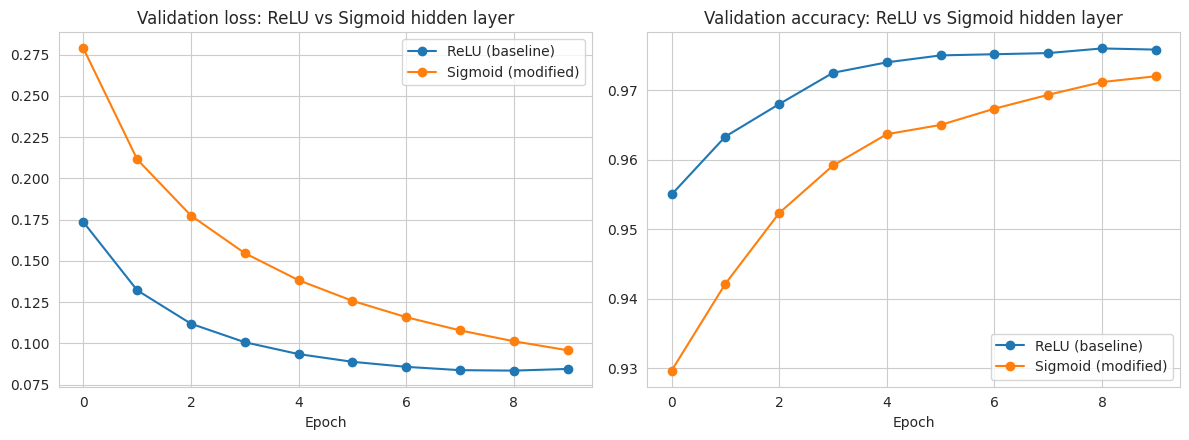

,Model,Test accuracy,Test loss,Epoch-1 val accuracy
0,Baseline (ReLU),0.9748,0.0803,0.9550
1,Modified (Sigmoid),0.9661,0.1105,0.9297


In [28]:
h_sig = history_sigmoid.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(h["val_loss"], marker="o", label="ReLU (baseline)")
axes[0].plot(h_sig["val_loss"], marker="o", label="Sigmoid (modified)")
axes[0].set_title("Validation loss: ReLU vs Sigmoid hidden layer")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(h["val_accuracy"], marker="o", label="ReLU (baseline)")
axes[1].plot(h_sig["val_accuracy"], marker="o", label="Sigmoid (modified)")
axes[1].set_title("Validation accuracy: ReLU vs Sigmoid hidden layer")
axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.show()

import pandas as pd
comparison = pd.DataFrame({
    "Model": ["Baseline (ReLU)", "Modified (Sigmoid)"],
    "Test accuracy": [test_accuracy, test_accuracy_sig],
    "Test loss": [test_loss, test_loss_sig],
    "Epoch-1 val accuracy": [h["val_accuracy"][0], h_sig["val_accuracy"][0]],
}).round(4)
comparison

**What changed, and why:**
- **What we changed:** only the hidden layer's activation function (`relu` → `sigmoid`);
  architecture, optimizer, epochs, batch size, and random seed were all kept identical.
- **What changed in the results:** the sigmoid version reaches a visibly *lower* validation
  accuracy in epoch 1 (slower start), and its curves sit consistently behind the ReLU baseline's
  for every epoch shown above — it ends training with a **lower final test accuracy** and
  **higher test loss** than the ReLU baseline.
- **Why:** sigmoid's output saturates toward 0 or 1 for inputs that are even moderately large in
  magnitude, and in that saturated region its gradient is close to zero — so, during
  backpropagation, weight updates flowing back through the hidden layer shrink. ReLU's gradient is
  a constant 1 for every positive input, so useful learning signal keeps flowing every epoch,
  producing the faster, higher-accuracy convergence seen above. This is exactly the effect Part D
  predicted from the shape of the two functions — now confirmed empirically rather than just asserted.

---
### Summary

A single-hidden-layer network (784 → 128 → 10) reaches roughly **97% test accuracy** on MNIST in
well under a minute of training — most of its remaining mistakes are genuinely ambiguous digit
pairs (like 9/4, 9/8, 7/2) rather than random errors. Swapping the hidden layer's activation from
ReLU to Sigmoid measurably slows convergence and costs a little final accuracy, giving concrete,
experimental evidence for why ReLU is the default choice in modern hidden layers.

